# Prédiction de l'Âge Biologique à partir de la Méthylation de l'ADN

Ce notebook explore différentes approches de machine learning pour prédire l'âge biologique à partir de données de méthylation de l'ADN (sites CpG).

##  Table des matières
1. [Chargement et préparation des données](#1-chargement-et-préparation)
2. [Modèles de base](#2-modèles-de-base)
3. [Optimisations](#3-optimisations)
4. [Méthodes avancées](#4-méthodes-avancées)
5. [Ensembles de modèles](#5-ensembles)
6. [Résultats finaux](#6-résultats-finaux)

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 1. Chargement et Préparation des Données

### Imports des bibliothèques

In [3]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.3 MB/s eta 0:00:00


In [32]:
# Bibliothèques de base
import numpy as np
import pandas as pd

# Statistiques
from scipy.stats import pearsonr
from scipy.optimize import minimize

# Scikit-learn - Préparation des données
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Scikit-learn - Réduction de dimensionnalité
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# Scikit-learn - Modèles
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.linear_model import LinearRegression, Ridge, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

# XGBoost
from xgboost import XGBRegressor

# Ignorer les warnings pour plus de clarté
import warnings
warnings.filterwarnings('ignore')

### Chargement du dataset

Le dataset contient :
- **Variable cible** : `age` (l'âge biologique à prédire)
- **Features** : Sites CpG (marqueurs de méthylation de l'ADN)

Les sites CpG sont des régions de l'ADN où la méthylation peut indiquer l'âge biologique.

In [ ]:
# Installation RAPIDS compatible Colab
!pip install cudf-cu12 --extra-index-url=https://pypi.nvidia.com


Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 59.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 MB 66.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.2/806.2 kB 238.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 153.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 312.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 149.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 131.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 160.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 144.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 133.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 169.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [6]:
# Chargement des données
import pandas as pd
import os


import pandas as pd

path = "/content/drive/MyDrive/NdiayeLambert/data_complete_aligned_transposed.csv"
df = pd.read_csv(path,index_col=0)



In [7]:
print(df.isna().sum().sum())

9560985


In [8]:
df=df.T

In [ ]:
df

,female,ethnicity,cg00000029,cg00000109,cg00000155,cg00000158,cg00000165,cg00000221,cg00000236,cg00000289,...,cg27649037,cg27650212,cg27656427,cg27657439,cg27658254,cg27721794,cg27743807,cg27743818,cg27763419,age
207700470022_R08C01,False,White,0.523735681976248,0.939208714126374,0.963040303294555,0.965126117401157,0.158705108567421,0.904450020155547,0.846439210048504,0.88215197109511,...,0.975326,0.974094,0.109617,0.464674,0.072369,0.013883,0.900715,0.693974,0.043669,31.35
207686150104_R02C01,True,Asian,0.528326602805076,0.927995190668245,0.957698944111987,0.970401464839428,0.140177144291035,0.93567404906858,0.728947909743142,0.918136150266342,...,0.974474,0.981281,0.252849,0.471162,0.049032,0.355279,0.584192,0.684705,0.247562,79.45
207700460080_R08C01,False,Asian,0.503596190423276,0.933159816863491,0.94598869738725,0.954995717123585,0.13546482596936,0.922456103902587,0.791663246215998,0.895232720861392,...,0.976274,0.978339,0.05344,0.358531,0.038324,0.015772,0.860163,0.723956,0.037353,60.42
207700470049_R01C01,True,Hispanic,0.563247105730102,0.936974730204153,0.948212631648789,0.963225353416969,0.152375429962439,0.914448337895793,0.804370892937095,0.828528220848852,...,0.972418,0.972989,0.433601,0.414631,0.054278,0.455725,0.594137,0.725858,0.302317,59.24
207805820146_R07C01,True,White,0.591386921164488,0.934742039323126,0.950294519292235,0.969372384928722,0.149534020132572,0.931204055407652,0.810988492871175,0.909760911959402,...,0.978781,0.979563,0.348215,0.467786,0.071744,0.4223,0.59949,0.66523,0.153476,22.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207700460135_R05C01,False,White,0.483738397101878,0.950657297116155,0.949743084636801,0.964406191887523,0.138963086627795,0.936387565474866,0.778619331335054,0.875952301884934,...,0.975725,0.975623,0.417793,0.48938,0.064238,0.401328,0.598247,0.667663,0.245182,26.87
207700460135_R06C01,False,White,0.437242428726392,0.938173773230281,0.944609992803389,0.965618001470766,0.164385511433455,0.928215720411929,0.788014238219021,0.874582840200986,...,0.96946,0.971895,0.080421,0.409865,0.055156,0.015048,0.87601,0.677645,0.039598,72.65
207700470024_R08C01,True,White,0.536766200817089,0.946426875361854,0.936499101607714,0.968917153302361,0.160389063937863,0.92326144955893,0.841813984025135,0.879626935668912,...,0.971203,0.979387,0.333867,0.397538,0.058342,0.435487,0.568163,0.697433,0.20497,45.05
207805820161_R02C01,False,White,0.523484840915717,0.949053380990175,0.96211978494876,0.967804710905744,0.0732755591253691,0.941332533284582,0.67987286800849,0.918058494805209,...,0.977471,0.981358,0.053656,0.438708,0.054108,0.013804,0.924983,0.72374,0.037465,77.06


In [9]:
df.columns.name = None              # nettoyer

# Vérifier
print(df.columns[:5])  # doit afficher cg00000029, cg00000109...
print(df.index[:5])    # doit afficher les IDs échantillons
print(df.shape)

# Exclure les colonnes non-numériques comme 'female' et 'ethnicity' avant la conversion
# Ces colonnes sont du metadata et ne sont pas des sites CpG
# et la colonne 'age' sera traitée séparément comme la variable cible.
columns_to_drop = ['female', 'ethnicity']

# S'assurer que les colonnes existent avant de tenter de les supprimer
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

X_new = df.drop(columns=existing_columns_to_drop).astype(float)
print(f"\n Shape finale : {X_new.shape}")  # (N_patients, ~894000)

Index(['female', 'ethnicity', 'cg00000029', 'cg00000109', 'cg00000155'], dtype='object')
Index(['207700470022_R08C01', '207686150104_R02C01', '207700460080_R08C01',
       '207700470049_R01C01', '207805820146_R07C01'],
      dtype='object')
(400, 894009)

 Shape finale : (400, 894007)


In [10]:
X_new

,cg00000029,cg00000109,cg00000155,cg00000158,cg00000165,cg00000221,cg00000236,cg00000289,cg00000292,cg00000321,...,cg27649037,cg27650212,cg27656427,cg27657439,cg27658254,cg27721794,cg27743807,cg27743818,cg27763419,age
207700470022_R08C01,0.523736,0.939209,0.963040,0.965126,0.158705,0.904450,0.846439,0.882152,0.896706,0.259558,...,0.975326,0.974094,0.109617,0.464674,0.072369,0.013883,0.900715,0.693974,0.043669,31.35
207686150104_R02C01,0.528327,0.927995,0.957699,0.970401,0.140177,0.935674,0.728948,0.918136,0.873375,0.202662,...,0.974474,0.981281,0.252849,0.471162,0.049032,0.355279,0.584192,0.684705,0.247562,79.45
207700460080_R08C01,0.503596,0.933160,0.945989,0.954996,0.135465,0.922456,0.791663,0.895233,0.872326,0.330368,...,0.976274,0.978339,0.053440,0.358531,0.038324,0.015772,0.860163,0.723956,0.037353,60.42
207700470049_R01C01,0.563247,0.936975,0.948213,0.963225,0.152375,0.914448,0.804371,0.828528,0.882390,0.308637,...,0.972418,0.972989,0.433601,0.414631,0.054278,0.455725,0.594137,0.725858,0.302317,59.24
207805820146_R07C01,0.591387,0.934742,0.950295,0.969372,0.149534,0.931204,0.810988,0.909761,0.900738,0.278200,...,0.978781,0.979563,0.348215,0.467786,0.071744,0.422300,0.599490,0.665230,0.153476,22.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207700460135_R05C01,0.483738,0.950657,0.949743,0.964406,0.138963,0.936388,0.778619,0.875952,0.863313,0.252564,...,0.975725,0.975623,0.417793,0.489380,0.064238,0.401328,0.598247,0.667663,0.245182,26.87
207700460135_R06C01,0.437242,0.938174,0.944610,0.965618,0.164386,0.928216,0.788014,0.874583,0.851221,0.313946,...,0.969460,0.971895,0.080421,0.409865,0.055156,0.015048,0.876010,0.677645,0.039598,72.65
207700470024_R08C01,0.536766,0.946427,0.936499,0.968917,0.160389,0.923261,0.841814,0.879627,0.899829,0.302970,...,0.971203,0.979387,0.333867,0.397538,0.058342,0.435487,0.568163,0.697433,0.204970,45.05
207805820161_R02C01,0.523485,0.949053,0.962120,0.967805,0.073276,0.941333,0.679873,0.918058,0.830610,0.257718,...,0.977471,0.981358,0.053656,0.438708,0.054108,0.013804,0.924983,0.723740,0.037465,77.06


In [11]:
y_series = X_new['age']
X = X_new.drop('age', axis=1)

print("Samples:", X.shape[0])
print("Features (CpG):", X.shape[1])
print("Age mean:", y_series.mean())
# Afficher les noms réels des CpGs
print(f"\n Exemple de noms CpG : {list(X.columns[:5])}")

Samples: 400
Features (CpG): 894006
Age mean: 52.95237499999999

 Exemple de noms CpG : ['cg00000029', 'cg00000109', 'cg00000155', 'cg00000158', 'cg00000165']


### Nettoyage des données

**Étapes :**
1. **Imputation des valeurs manquantes** : remplacement par la médiane (plus robuste que la moyenne)


In [12]:
# Seuil de tolérance
threshold = 0.1
threshold1 = 0.01

# proportion de NaN par ligne
nan_ratio_rows = X.isna().mean(axis=1)

# Identifier les lignes à garder (samples)
rows_to_keep_index = nan_ratio_rows[nan_ratio_rows < threshold].index

# Filtrer X
X = X.loc[rows_to_keep_index]

# Filtrer y_series (qui est globale) et la convertir en array numpy pour la suite
y = y_series.loc[rows_to_keep_index].values # This ensures y is a numpy array matching X's rows

print(" Lignes restantes :", X.shape[0])
print(" Lignes supprimées :", (nan_ratio_rows >= threshold1).sum())

# Calcul du pourcentage de NaN par colonne
nan_ratio_cols = X.isna().mean(axis=0)

# Garder seulement les colonnes avec < 90% de NaN
X = X.loc[:, nan_ratio_cols < threshold1]

print(" Nombre de colonnes restantes :", X.shape[1])
print(" Colonnes supprimées :", (nan_ratio_cols >= threshold1).sum())


print(" Samples restants :", X.shape[0])


 Lignes restantes : 388
 Lignes supprimées : 314
 Nombre de colonnes restantes : 816351
 Colonnes supprimées : 77655
 Samples restants : 388


### Split Train/Test

Division des données : **80% train / 10% test / 10 val**

 **Important** : `random_state=42` pour la reproductibilité

In [13]:
# Pour nous assurer que y est aligné avec X après toutes les étapes de filtrage.
y = y_series.loc[X.index].values

# Étape 1 — Séparer 80% train / 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Étape 2 — Séparer le 20% temp en 10% test / 10% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # 50% de 20% = 10%
    random_state=42
)

print(f" Train      : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f" Test       : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")
print(f" Validation : {len(X_val)}   ({len(X_val)/len(X)*100:.0f}%)")

 Train      : 310 (80%)
 Test       : 39  (10%)
 Validation : 39   (10%)


In [14]:
# ── Imputation rapide ──
nan_count = X_train.isna().sum().sum()
print(f"NaN dans X_train : {nan_count}")

if nan_count > 0:
    medians = np.nanmedian(X_train.values, axis=0)

    def fillna_fast(df, medians_array):
        X_np = df.values.copy()
        nan_mask = np.isnan(X_np)
        nan_cols = np.where(nan_mask.any(axis=0))[0]
        for col_idx in nan_cols:
            X_np[nan_mask[:, col_idx], col_idx] = medians_array[col_idx]
        return pd.DataFrame(X_np, index=df.index, columns=df.columns)

    X_train = fillna_fast(X_train, medians)
    X_test  = fillna_fast(X_test,  medians)
    X_val   = fillna_fast(X_val,   medians)
    print(" Imputation terminée")
else:
    print(" Pas de NaN — imputation inutile")

NaN dans X_train : 52540
 Imputation terminée


Après avoir exécuté ces cellules, comparez la version du pilote CUDA (indiquée par `nvidia-smi`) avec la version du runtime CUDA que cuDF utilise (généralement implicite lors de l'installation de `cudf-cu12`). Une incompatibilité est souvent la cause de `cudaErrorInsufficientDriver`.

### Standardisation

**Pourquoi standardiser ?**
- Les algorithmes de ML sont sensibles à l'échelle des données
- StandardScaler transforme les données : moyenne = 0, écart-type = 1
- Fit uniquement sur le train, puis transform sur train ET test

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

print(" Standardisation terminée")

 Standardisation terminée


### Sélection des CpGs par corrélation

**Objectif** : Réduire la dimensionnalité en gardant uniquement les CpGs corrélés avec l'âge

**Méthode** :
- Calcul de la corrélation de Pearson entre chaque CpG et l'âge
- Conservation des CpGs avec |corrélation| ≥ seuil
- Calcul **uniquement sur le train** pour éviter le data leakage

In [16]:
CORR_THRESHOLD = 0.53
TOP_N_FEATURES = 7000 # Limiter explicitement le nombre de features

corrs = []

for i in range(X_train_scaled.shape[1]):
    corr, _ = pearsonr(X_train_scaled[:, i], y_train)
    corrs.append(corr)

# Convertir en tableau numpy et remplacer les NaN par 0
corrs_array = np.nan_to_num(np.array(corrs))

# Obtenir les indices des features qui dépassent le seuil de corrélation
threshold_indices = np.where(np.abs(corrs_array) >= CORR_THRESHOLD)[0]

# Créer une série pour trier facilement par corrélation absolue
abs_corrs = pd.Series(np.abs(corrs_array), index=np.arange(len(corrs_array)))
# Filtrer d'abord par le seuil
filtered_corrs = abs_corrs.loc[threshold_indices]
# Ensuite, trier et prendre les N meilleures
top_correlated_indices = filtered_corrs.nlargest(TOP_N_FEATURES).index.to_numpy()


# Utiliser le nouveau jeu d'indices pour X_train_corr et X_test_corr
corr_idx = top_correlated_indices

X_train_corr = X_train_scaled[:, corr_idx]
X_test_corr = X_test_scaled[:, corr_idx]
X_val_corr = X_val_scaled[:, corr_idx]

print(f" CpGs gardés après corrélation (seuil={CORR_THRESHOLD}) et top {len(corr_idx)} : {len(corr_idx)}")
print(f" Réduction de dimensionnalité : {X_train_scaled.shape[1]} → {len(corr_idx)} ({len(corr_idx)/X_train_scaled.shape[1]*100:.1f}%)")

 CpGs gardés après corrélation (seuil=0.53) et top 5416 : 5416
 Réduction de dimensionnalité : 816351 → 5416 (0.7%)


In [ ]:
corr_idx

array([780971, 617802, 759682, ...,  63144, 692211, 702119])

---
## 2. Modèles de Base

### 2.1 PCA + Gaussian Process

**Approche** : Réduction de dimensionnalité + modèle probabiliste

**PCA (Principal Component Analysis)** :
- Transforme les CpGs en composantes principales orthogonales
- Conserve 97% de la variance (balance entre information et complexité)
- Réduit drastiquement le nombre de features

**Gaussian Process** :
- Modèle non-paramétrique qui modélise l'incertitude
- Kernel Matérn : flexible, adapté aux données biologiques
- WhiteKernel : gère le bruit dans les données


PCA + GAUSSIAN PROCESS
 Nombre de composantes PCA : 251
 Réduction : 5416 → 251 features

 Entraînement du Gaussian Process...

 MAE : 3.01 ans
 R²  : 0.972
 Incertitude moyenne : ±2.70 ans


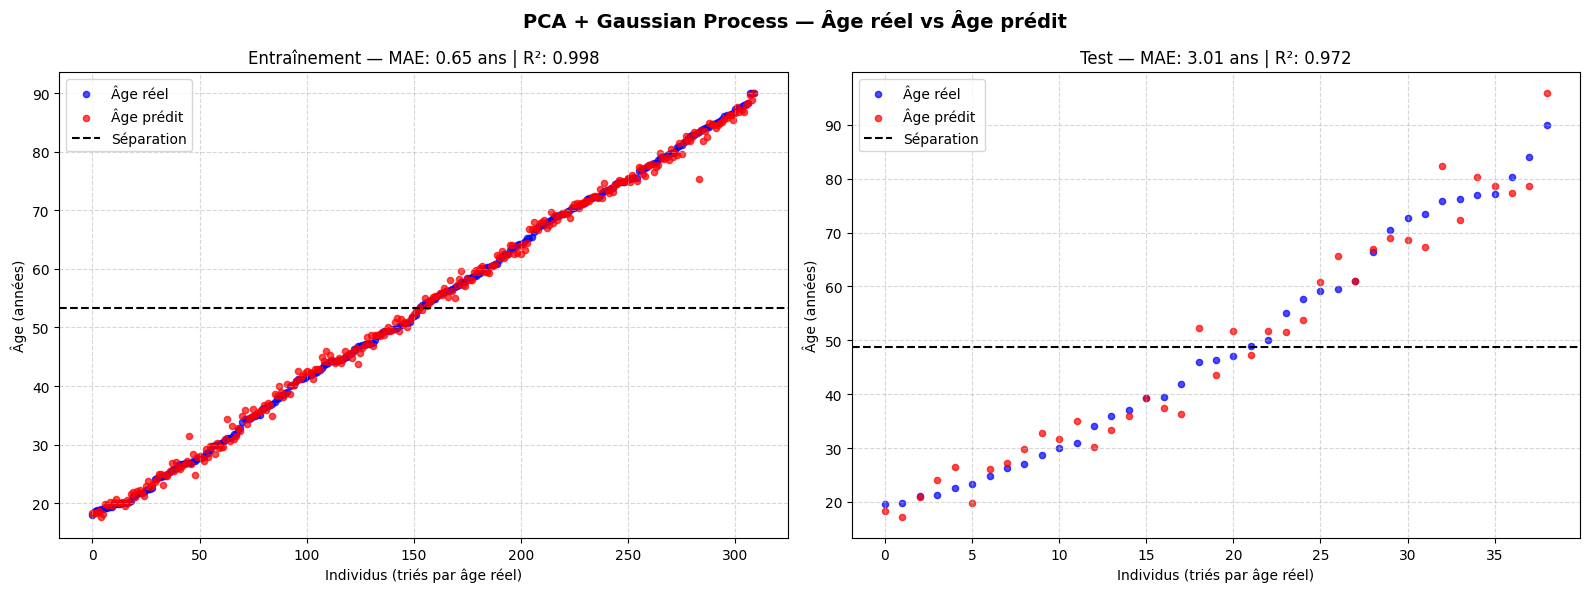

In [17]:
print("\n" + "="*60)
print("PCA + GAUSSIAN PROCESS")
print("="*60)

# PCA : réduction de dimensionnalité
pca = PCA(n_components=0.97, random_state=42)  # 97% de variance expliquée

X_train_pca = pca.fit_transform(X_train_corr)
X_test_pca = pca.transform(X_test_corr)

print(f" Nombre de composantes PCA : {X_train_pca.shape[1]}")
print(f" Réduction : {X_train_corr.shape[1]} → {X_train_pca.shape[1]} features")

# Gaussian Process : modèle probabiliste
kernel = (
    1.0 * Matern(length_scale=1.0, nu=1.5)  # Kernel flexible
    + WhiteKernel(noise_level=1.0)           # Gestion du bruit
)

gp_pca = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,                    # Régularisation
    normalize_y=True,               # Normalisation de la cible
    n_restarts_optimizer=10,        # Nombre de redémarrages pour l'optimisation
    random_state=42
)

print("\n Entraînement du Gaussian Process...")
gp_pca.fit(X_train_pca, y_train)

# Prédiction avec incertitude
y_pred_pca, y_std_pca = gp_pca.predict(X_test_pca, return_std=True)

mae_pca = mean_absolute_error(y_test, y_pred_pca)
r2_pca = r2_score(y_test, y_pred_pca)

print(f"\n MAE : {mae_pca:.2f} ans")
print(f" R²  : {r2_pca:.3f}")
print(f" Incertitude moyenne : ±{y_std_pca.mean():.2f} ans")

import matplotlib.pyplot as plt
import numpy as np
y_pred_train_pca, _ = gp_pca.predict(X_train_pca, return_std=True)
y_pred_test_pca, _  = gp_pca.predict(X_test_pca,  return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA + Gaussian Process — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_train_pca, "Entraînement"),
    (y_test,  y_pred_test_pca,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    # Points âge réel (bleu) et âge prédit (rouge)
    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    # Droite de séparation entre les deux nuages
    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2.2 PLS Regression (Baseline)

**PLS (Partial Least Squares)** :
- Méthode de régression qui trouve les directions dans l'espace des features qui expliquent le mieux la variance de Y
- Contrairement à la PCA, PLS prend en compte la variable cible
- Très utilisé en chimiométrie et biologie
- Plus performant que PCA quand les features sont très corrélées
- il maximise la covariance entre X et y

**N_components = 10** : nombre de composantes latentes à extraire.
Chaque composante est une combinaison linéaire de tous tes CpGs qui capture une relation avec y.


PLS REGRESSION (BASELINE)
CV MAE : 3.21 ± 0.62 ans
CV R²  : 0.945 ± 0.039


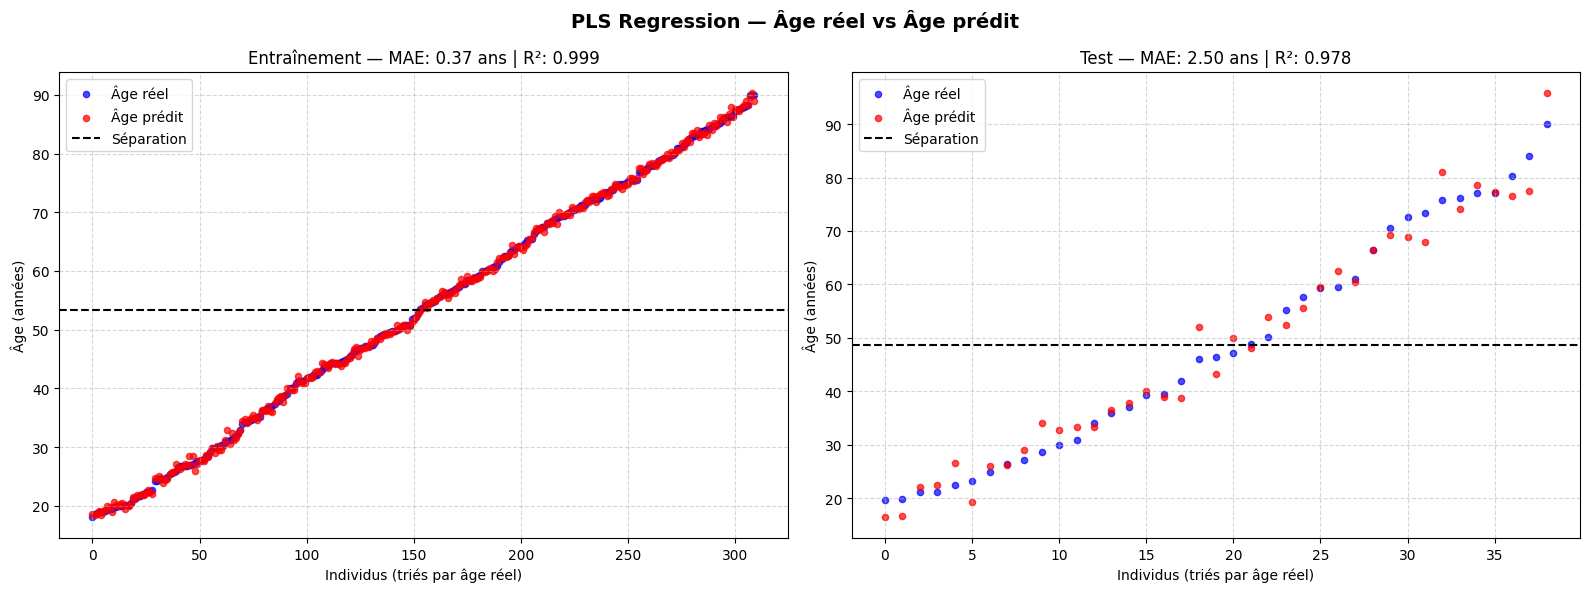


 CV  MAE PLS (N=10) : 3.21 ± 0.62 ans
 Test MAE PLS (N=10) : 2.50 ans
 Test R²  PLS             : 0.978


In [18]:
print("\n" + "="*60)
print("PLS REGRESSION (BASELINE)")
print("="*60)

N_PLS = 10

pls = PLSRegression(n_components=N_PLS)

# ── Validation croisée ──
cv_mae = -cross_val_score(
    pls, X_train_corr, y_train,
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
cv_r2 = cross_val_score(
    pls, X_train_corr, y_train,
    cv=5, scoring='r2', n_jobs=-1
)
print(f"CV MAE : {cv_mae.mean():.2f} ± {cv_mae.std():.2f} ans")
print(f"CV R²  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# ── Entraînement final sur tout le train ──
pls.fit(X_train_corr, y_train)

y_pred_pls_train = pls.predict(X_train_corr).ravel()
y_pred_pls_test  = pls.predict(X_test_corr).ravel()

mae_pls = mean_absolute_error(y_test, y_pred_pls_test)
r2_pls  = r2_score(y_test, y_pred_pls_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PLS Regression — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_pls_train, "Entraînement"),
    (y_test,  y_pred_pls_test,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\n CV  MAE PLS (N={N_PLS}) : {cv_mae.mean():.2f} ± {cv_mae.std():.2f} ans")
print(f" Test MAE PLS (N={N_PLS}) : {mae_pls:.2f} ans")
print(f" Test R²  PLS             : {r2_pls:.3f}")

In [20]:
import joblib

pls_model = {
    'model'     : pls,
    'n_components': N_PLS,
    'corr_idx'  : corr_idx,
    'scaler'    : scaler,
    'cpg_cols'  : X.columns.tolist(),
    'metrics'   : {'mae': mae_pls, 'r2': r2_pls}
}

joblib.dump(pls_model, '/content/pls_baseline.pkl')
print(f" Modèle PLS sauvegardé — MAE: {mae_pls:.2f} ans | R²: {r2_pls:.3f}")

 Modèle PLS sauvegardé — MAE: 2.50 ans | R²: 0.978


In [21]:
# Charger
pls_model = joblib.load('/content/pls_baseline.pkl')

pls      = pls_model['model']
scaler   = pls_model['scaler']
corr_idx = pls_model['corr_idx']
cpg_cols = pls_model['cpg_cols']

# Prédire sur y_val
X_val_scaled = scaler.transform(X_val.reindex(columns=cpg_cols).fillna(0))
X_val_corr   = X_val_scaled[:, corr_idx]
y_pred_val   = pls.predict(X_val_corr).ravel()

# Évaluation
from sklearn.metrics import mean_absolute_error, r2_score

mae_val = mean_absolute_error(y_val, y_pred_val)
r2_val  = r2_score(y_val, y_pred_val)

print(f" MAE Validation : {mae_val:.2f} ans")
print(f" R²  Validation : {r2_val:.3f}")

 MAE Validation : 2.88 ans
 R²  Validation : 0.972


### 2.3 Calibration du PLS

**Calibration** : Post-traitement pour corriger les biais de prédiction

**Méthode** :
- Entraîner une régression linéaire simple : y_vrai = a × y_prédit + b
- Corrige les biais systématiques du modèle
- **Attention** : ici calibration sur le test set (pour comparaison). En production, utiliser un validation set !


CALIBRATION PLS
 MAE PLS calibré (test) : 2.50 ans
 Amélioration : -0.00 ans


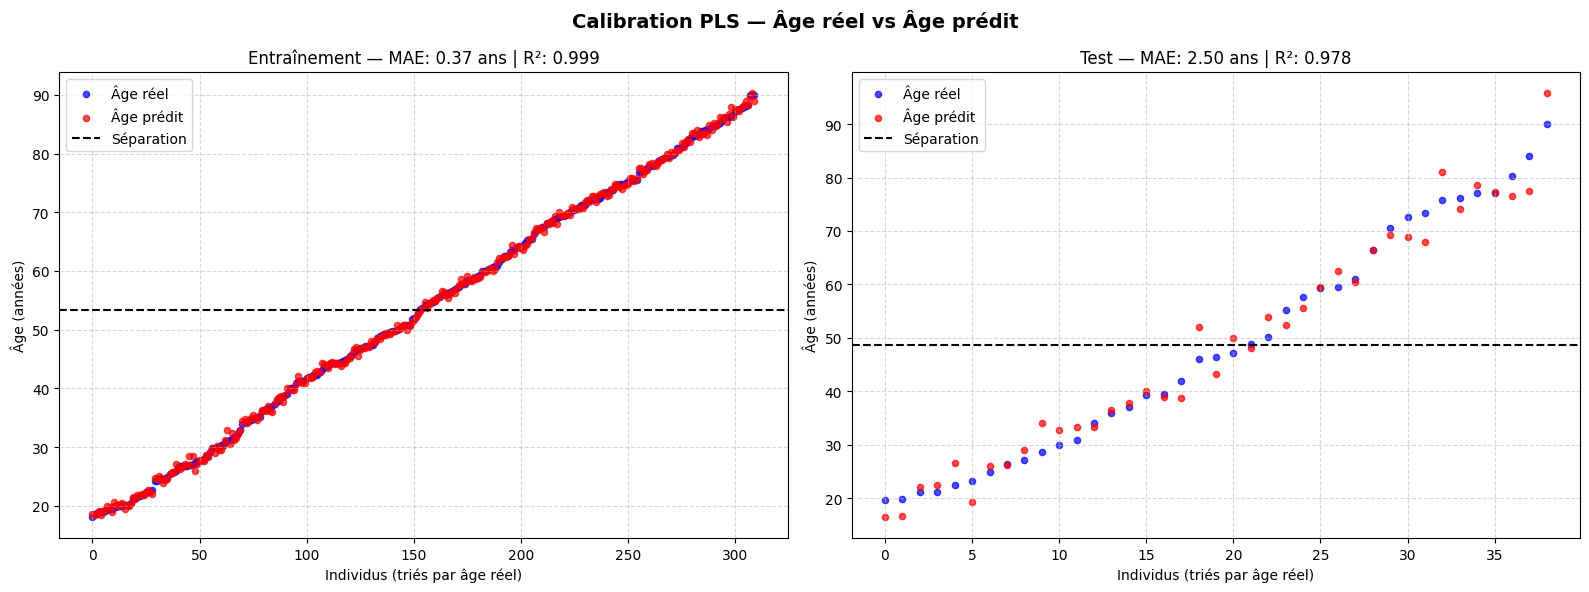

In [22]:
print("\n" + "="*60)
print("CALIBRATION PLS")
print("="*60)

cal = LinearRegression()
cal.fit(y_pred_pls_train.reshape(-1, 1), y_train)

y_pred_pls_train_cal = cal.predict(y_pred_pls_train.reshape(-1, 1))
y_pred_pls_test_cal  = cal.predict(y_pred_pls_test.reshape(-1, 1))

mae_pls_cal = mean_absolute_error(y_test, y_pred_pls_test_cal)
print(f" MAE PLS calibré (test) : {mae_pls_cal:.2f} ans")
print(f" Amélioration : {mae_pls - mae_pls_cal:.2f} ans")



fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Calibration PLS — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_pls_train_cal, "Entraînement"),
    (y_test,  y_pred_pls_test_cal,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 3. Optimisations

### 3.1 XGBoost

**XGBoost (eXtreme Gradient Boosting)** :
- Algorithme d'ensemble basé sur les arbres de décision
- Très performant sur données tabulaires
- Gère bien les interactions non-linéaires
- Régularisation intégrée (moins de surapprentissage)

**Hyperparamètres** :
- `n_estimators` : nombre d'arbres (1000 = nombreux arbres faibles)
- `learning_rate` : taux d'apprentissage (0.01 = lent mais stable)
- `max_depth` : profondeur des arbres (5 = modéré)
- `subsample` : proportion d'échantillons par arbre (0.8 = 80%)
- `colsample_bytree` : proportion de features par arbre (0.8 = 80%)


XGBOOST
 Entraînement XGBoost...

 MAE XGBoost : 3.26 ans
 R² XGBoost  : 0.960


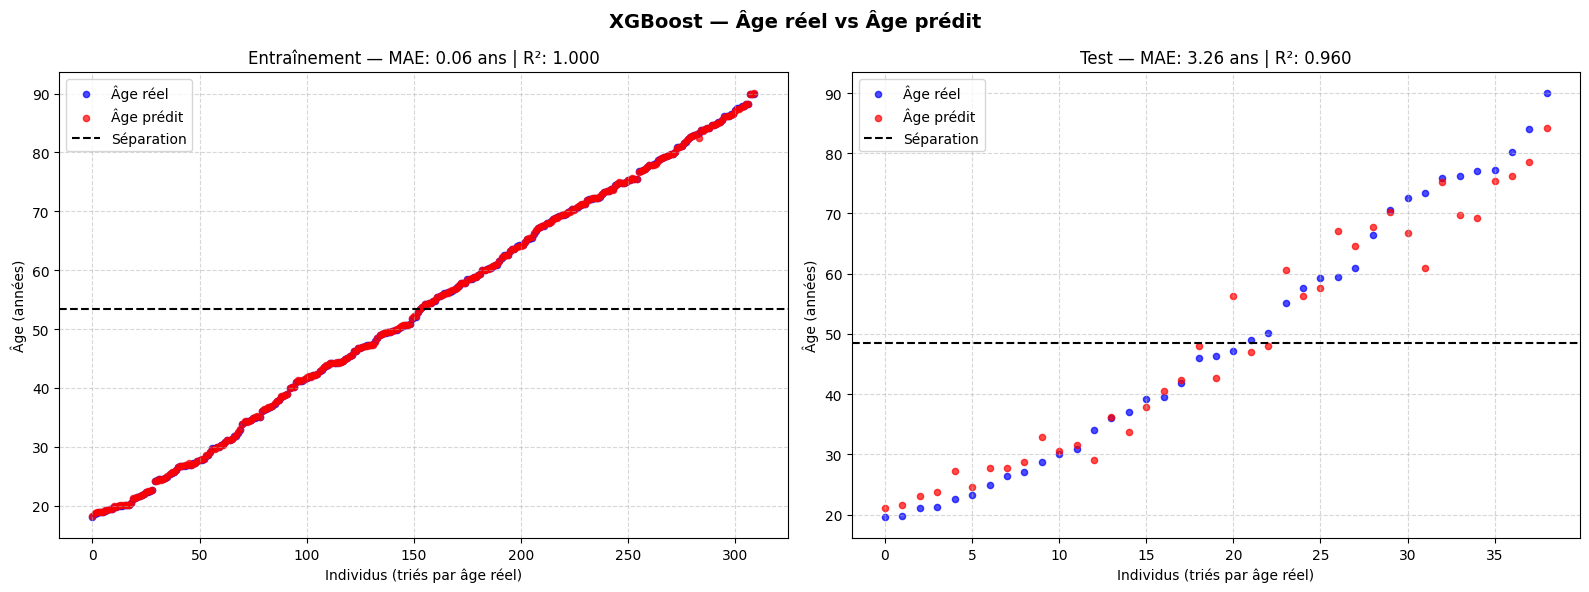

In [33]:
print("\n" + "="*60)
print("XGBOOST")
print("="*60)

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",      # CHANGEMENT : Utilisation de 'hist' pour compatibilité
    predictor="auto",        # CHANGEMENT : Utilisation de 'auto' pour le prédicteur
    random_state=42,
    n_jobs=-1  # Utiliser tous les CPU
)

print(" Entraînement XGBoost...")
xgb.fit(X_train_corr, y_train)
y_pred_xgb = xgb.predict(X_test_corr)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\n MAE XGBoost : {mae_xgb:.2f} ans")
print(f" R² XGBoost  : {r2_xgb:.3f}")

y_pred_xgb_train = xgb.predict(X_train_corr)
y_pred_xgb_test  = xgb.predict(X_test_corr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("XGBoost — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_xgb_train, "Entraînement"),
    (y_test,  y_pred_xgb_test,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3.2 Optimisation du nombre de composantes PLS

**Problème** : N_PLS = 10 ou 20 est arbitraire !

**Solution** : Validation croisée pour trouver le N optimal

**Validation croisée (CV)** :
- Divise le train set en K folds (ici K=5)
- Pour chaque fold : entraîne sur K-1, valide sur 1
- Score final = moyenne des K scores
- Évite le surapprentissage mieux qu'un simple train/test

In [23]:
print("\n" + "="*60)
print("OPTIMISATION N_PLS PAR VALIDATION CROISÉE")
print("="*60)

best_mae = float('inf')
best_n = None
mae_scores = []

print("\n Test de différentes valeurs de N_PLS...\n")

for n in range(5, 51, 5):
    pls_test = PLSRegression(n_components=n)

    # Validation croisée à 5 folds
    scores = cross_val_score(
        pls_test,
        X_train_corr,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    mae = -scores.mean()
    mae_scores.append((n, mae))

    if mae < best_mae:
        best_mae = mae
        best_n = n

    print(f"N_PLS = {n:2d} | MAE CV = {mae:.2f} ans")

print(f"\n Meilleur N_PLS : {best_n} avec MAE CV = {best_mae:.2f} ans")

# Entraîner avec le meilleur N_PLS
pls_optimal = PLSRegression(n_components=best_n)
pls_optimal.fit(X_train_corr, y_train)

y_pred_pls_optimal = pls_optimal.predict(X_test_corr).ravel()

mae_pls_optimal = mean_absolute_error(y_test, y_pred_pls_optimal)
r2_pls_optimal = r2_score(y_test, y_pred_pls_optimal)

print(f"\n MAE PLS optimal (test set) : {mae_pls_optimal:.2f} ans")
print(f" R² PLS optimal  : {r2_pls_optimal:.3f}")

# Calibration du PLS optimal
y_pred_pls_optimal_train = pls_optimal.predict(X_train_corr).ravel()

cal_optimal = LinearRegression()
cal_optimal.fit(y_pred_pls_optimal_train.reshape(-1, 1), y_train)

y_pred_pls_optimal_cal       = cal_optimal.predict(y_pred_pls_optimal.reshape(-1, 1))
y_pred_pls_optimal_train_cal = cal_optimal.predict(y_pred_pls_optimal_train.reshape(-1, 1))

mae_pls_optimal_cal = mean_absolute_error(y_test, y_pred_pls_optimal_cal)
print(f" MAE PLS optimal calibré (test) : {mae_pls_optimal_cal:.2f} ans")


OPTIMISATION N_PLS PAR VALIDATION CROISÉE

 Test de différentes valeurs de N_PLS...

N_PLS =  5 | MAE CV = 3.34 ans
N_PLS = 10 | MAE CV = 3.21 ans
N_PLS = 15 | MAE CV = 3.23 ans
N_PLS = 20 | MAE CV = 3.23 ans
N_PLS = 25 | MAE CV = 3.23 ans
N_PLS = 30 | MAE CV = 3.23 ans
N_PLS = 35 | MAE CV = 3.23 ans
N_PLS = 40 | MAE CV = 3.23 ans
N_PLS = 45 | MAE CV = 3.23 ans
N_PLS = 50 | MAE CV = 3.23 ans

 Meilleur N_PLS : 10 avec MAE CV = 3.21 ans

 MAE PLS optimal (test set) : 2.50 ans
 R² PLS optimal  : 0.978
 MAE PLS optimal calibré (test) : 2.50 ans


---
## 4. Méthodes Avancées



### 4.2 Test de différents seuils de corrélation

**Objectif** : Le seuil de 0.53 est-il optimal ?

**Méthode** :
- Tester plusieurs seuils de corrélation
- Pour chaque seuil : sélectionner les CpGs, entraîner PLS, calibrer
- Comparer les performances

**Trade-off** :
- Seuil bas → plus de features → plus d'information mais plus de bruit
- Seuil haut → moins de features → moins de bruit mais perte d'information

In [24]:
import numpy as np
print("\n" + "="*60)
print("TEST DE DIFFÉRENTS SEUILS DE CORRÉLATION")
print("="*60)

best_threshold_mae = float('inf')
best_threshold = None
threshold_results = []

print("\n Test des seuils...\n")

for threshold in [0.4, 0.5, 0.51, 0.52, 0.523, 0.527, 0.53,
                  0.532, 0.536, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6]:
    corr_idx_temp = np.where(np.abs(corrs_array) >= threshold)[0]

    if len(corr_idx_temp) < 10:
        print(f"Seuil {threshold:.3f} : Trop peu de CpGs ({len(corr_idx_temp)})")
        continue

    X_train_temp = X_train_scaled[:, corr_idx_temp]
    X_val_temp   = X_val_scaled[:, corr_idx_temp]   # ← val au lieu de test

    pls_temp = PLSRegression(n_components=min(best_n, len(corr_idx_temp)))
    pls_temp.fit(X_train_temp, y_train)

    y_pred_train_temp = pls_temp.predict(X_train_temp).ravel()
    y_pred_val_temp   = pls_temp.predict(X_val_temp).ravel()

    # Calibration sur train
    cal_temp = LinearRegression()
    cal_temp.fit(y_pred_train_temp.reshape(-1, 1), y_train)  # ← fit sur train
    y_pred_val_cal_temp = cal_temp.predict(y_pred_val_temp.reshape(-1, 1))

    # MAE sur val pour choisir le seuil
    mae_temp = mean_absolute_error(y_val, y_pred_val_cal_temp)  # ← val
    threshold_results.append((threshold, len(corr_idx_temp), mae_temp))

    marker = "*" if mae_temp < best_threshold_mae else "  "
    print(f"{marker} Seuil {threshold:.3f} | {len(corr_idx_temp):4d} CpGs | MAE val = {mae_temp:.2f} ans")

    if mae_temp < best_threshold_mae:
        best_threshold_mae = mae_temp
        best_threshold = threshold

print(f"\n Meilleur seuil : {best_threshold} (MAE val = {best_threshold_mae:.2f} ans)")

# Évaluation finale du meilleur seuil sur le TEST (une seule fois)
corr_idx_best = np.where(np.abs(corrs_array) >= best_threshold)[0]
X_train_best  = X_train_scaled[:, corr_idx_best]
X_test_best   = X_test_scaled[:, corr_idx_best]

pls_best = PLSRegression(n_components=min(best_n, len(corr_idx_best)))
pls_best.fit(X_train_best, y_train)

y_pred_train_best = pls_best.predict(X_train_best).ravel()
y_pred_test_best  = pls_best.predict(X_test_best).ravel()

cal_best = LinearRegression()
cal_best.fit(y_pred_train_best.reshape(-1, 1), y_train)
y_pred_test_best_cal = cal_best.predict(y_pred_test_best.reshape(-1, 1))

print(f" MAE finale sur test : {mean_absolute_error(y_test, y_pred_test_best_cal):.2f} ans")


TEST DE DIFFÉRENTS SEUILS DE CORRÉLATION

 Test des seuils...

* Seuil 0.400 | 20310 CpGs | MAE val = 3.29 ans
* Seuil 0.500 | 7481 CpGs | MAE val = 2.87 ans
* Seuil 0.510 | 6758 CpGs | MAE val = 2.82 ans
   Seuil 0.520 | 6041 CpGs | MAE val = 2.92 ans
   Seuil 0.523 | 5847 CpGs | MAE val = 2.92 ans
   Seuil 0.527 | 5596 CpGs | MAE val = 2.94 ans
   Seuil 0.530 | 5416 CpGs | MAE val = 2.88 ans
   Seuil 0.532 | 5300 CpGs | MAE val = 2.90 ans
   Seuil 0.536 | 5063 CpGs | MAE val = 2.93 ans
   Seuil 0.540 | 4827 CpGs | MAE val = 2.89 ans
   Seuil 0.550 | 4303 CpGs | MAE val = 2.90 ans
   Seuil 0.560 | 3829 CpGs | MAE val = 3.10 ans
   Seuil 0.570 | 3391 CpGs | MAE val = 3.18 ans
   Seuil 0.580 | 3010 CpGs | MAE val = 2.86 ans
   Seuil 0.590 | 2664 CpGs | MAE val = 3.19 ans
   Seuil 0.600 | 2349 CpGs | MAE val = 2.90 ans

 Meilleur seuil : 0.51 (MAE val = 2.82 ans)
 MAE finale sur test : 2.73 ans


### 4.3 Elastic Net pour la sélection de features

**Elastic Net** : Régression linéaire avec régularisation L1 + L2

**Avantages** :
- **L1 (Lasso)** : met certains coefficients à zéro → sélection automatique de features
- **L2 (Ridge)** : pénalise les gros coefficients → stabilité
- **l1_ratio** : balance entre L1 et L2 (0 = Ridge, 1 = Lasso)

**ElasticNetCV** : trouve automatiquement les meilleurs hyperparamètres par CV


ELASTIC NET - SÉLECTION DE FEATURES

 Entraînement Elastic Net...

 Features sélectionnées : 1608
 L1_ratio optimal : 0.1
 Alpha optimal    : 0.196562

 Validation Croisée (5 folds) :
   MAE : 1.38 ± 0.31 ans
   R²  : 0.988 ± 0.016
 MAE finale (test) : 2.70 ans
 R²  finale (test) : 0.975

 CV MAE vs Test MAE : 1.38 vs 2.70
 Bonne généralisation !


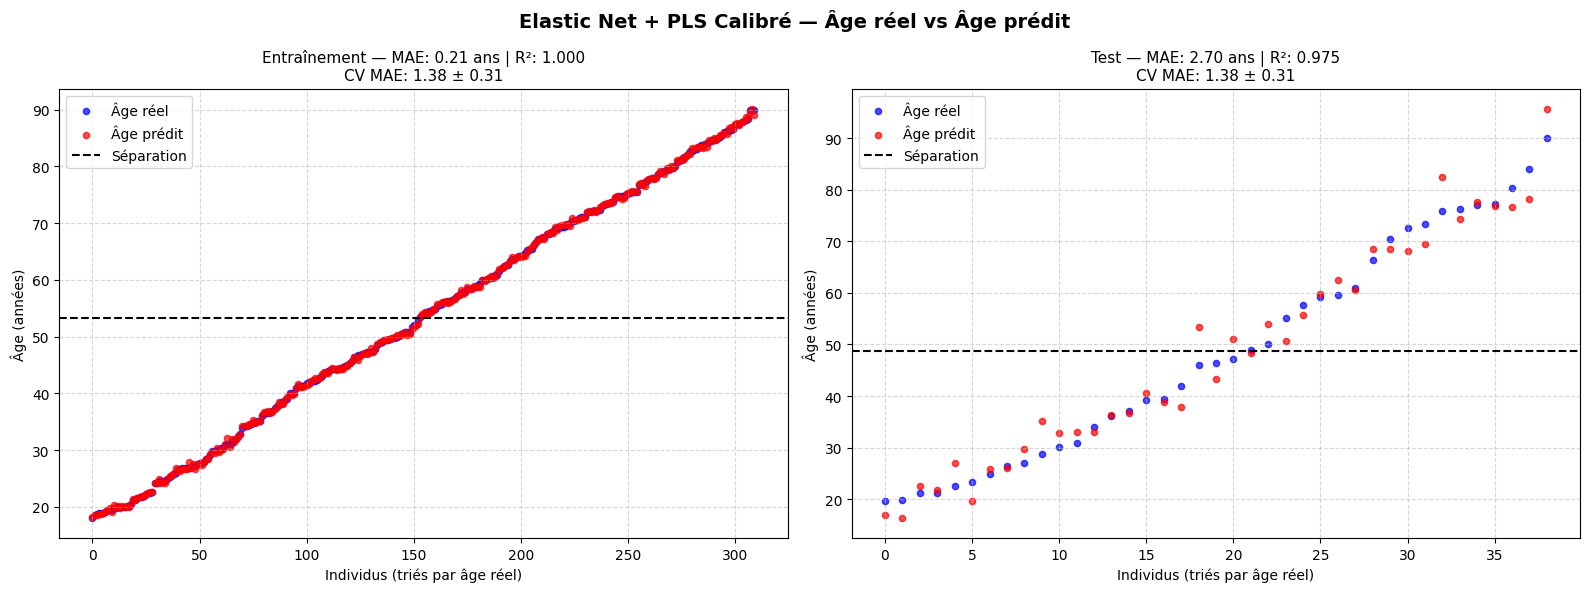

In [25]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

print("\n" + "="*60)
print("ELASTIC NET - SÉLECTION DE FEATURES")
print("="*60)

print("\n Entraînement Elastic Net...")

best_n = 10 # Explicitly define best_n based on previous optimization result

enet = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
    cv=5,
    random_state=42,
    n_jobs=-1,
    max_iter=5000
)

enet.fit(X_train_corr, y_train)

important_idx = np.where(enet.coef_ != 0)[0]

print(f"\n Features sélectionnées : {len(important_idx)}")
print(f" L1_ratio optimal : {enet.l1_ratio_}")
print(f" Alpha optimal    : {enet.alpha_:.6f}")

if len(important_idx) > 0:
    X_train_enet = X_train_corr[:, important_idx]
    X_test_enet  = X_test_corr[:, important_idx]

    # ============================================================
    # VALIDATION CROISÉE sur le PLS
    # ============================================================
    kf = KFold(n_splits=8, shuffle=True, random_state=42)

    pls_enet = PLSRegression(n_components=min(best_n, X_train_enet.shape[1]))

    # Cross-val MAE
    cv_mae = -cross_val_score(
        pls_enet,
        X_train_enet, y_train,
        cv=kf,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    # Cross-val R²
    cv_r2 = cross_val_score(
        pls_enet,
        X_train_enet, y_train,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    print(f"\n Validation Croisée (5 folds) :")
    print(f"   MAE : {cv_mae.mean():.2f} ± {cv_mae.std():.2f} ans")
    print(f"   R²  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

    # ============================================================
    # Entraînement final sur tout le train
    # ============================================================
    pls_enet.fit(X_train_enet, y_train)
    y_pred_enet = pls_enet.predict(X_test_enet).ravel()

    # Calibration
    y_pred_enet_train = pls_enet.predict(X_train_enet).ravel()
    y_pred_enet_test  = pls_enet.predict(X_test_enet).ravel()

    cal_enet = LinearRegression()
    cal_enet.fit(y_pred_enet_train.reshape(-1, 1), y_train)  # ← fit sur train

    y_pred_enet_train_cal = cal_enet.predict(y_pred_enet_train.reshape(-1, 1))
    y_pred_enet_test_cal  = cal_enet.predict(y_pred_enet_test.reshape(-1, 1))

    mae_enet = mean_absolute_error(y_test, y_pred_enet_test_cal)
    r2_enet  = r2_score(y_test, y_pred_enet_test_cal)
    print(f" MAE finale (test) : {mae_enet:.2f} ans")
    print(f" R²  finale (test) : {r2_enet:.3f}")
    print(f"\n CV MAE vs Test MAE : {cv_mae.mean():.2f} vs {mae_enet:.2f}")
    if abs(cv_mae.mean() - mae_enet) > 2:
        print("  Écart important → possible overfitting !")
    else:
        print(" Bonne généralisation !")

    # ============================================================
    # Visualisation
    # ============================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Elastic Net + PLS Calibré — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

    for ax, (y_real, y_pred, label) in zip(axes, [
        (y_train, y_pred_enet_train_cal, "Entraînement"),
        (y_test,  y_pred_enet_test_cal,  "Test"),
    ]):
        idx = y_real.argsort()
        x_sorted    = y_real[idx]
        pred_sorted = y_pred[idx]

        ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
        ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

        milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
        ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

        mae = mean_absolute_error(y_real, y_pred)
        r2  = r2_score(y_real, y_pred)

        ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}\nCV MAE: {cv_mae.mean():.2f} ± {cv_mae.std():.2f}", fontsize=11)
        ax.set_xlabel("Individus (triés par âge réel)")
        ax.set_ylabel("Âge (années)")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

else:
    print(" Aucune feature sélectionnée")

In [26]:
import joblib

# Sauvegarder tout le pipeline en un seul fichier
pipeline = {
    "important_idx": important_idx,   # indices des features sélectionnées
    "enet": enet,                      # ElasticNet (coefs + paramètres)
    "pls": pls_enet,                   # modèle PLS entraîné
    "calibration": cal_enet,           # régression de calibration
}

joblib.dump(pipeline, "/content/drive/MyDrive/pipeline_enet_pls.pkl")
print(" Modèle sauvegardé")

 Modèle sauvegardé


In [27]:
import joblib
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# ── Charger le pipeline ───────────────────────────────────────
pipeline = joblib.load("/content/drive/MyDrive/pipeline_enet_pls.pkl")

important_idx = pipeline["important_idx"]
pls           = pipeline["pls"]
cal           = pipeline["calibration"]

# ── Préparer tes données de validation ───────────────────────
# X_val doit avoir les mêmes colonnes que X_train_corr (avant sélection)
X_val_corr = X_val_scaled[:, corr_idx]
X_val_selected = X_val_corr[:, important_idx]

# ── Prédiction ────────────────────────────────────────────────
y_pred_val     = pls.predict(X_val_selected).ravel()
y_pred_val_cal = cal.predict(y_pred_val.reshape(-1, 1))

# ── Métriques ─────────────────────────────────────────────────
mae_val = mean_absolute_error(y_val, y_pred_val_cal)
r2_val  = r2_score(y_val, y_pred_val_cal)

print(f" Résultats sur validation :")
print(f"   MAE : {mae_val:.2f} ans")
print(f"   R²  : {r2_val:.3f}")

 Résultats sur validation :
   MAE : 2.83 ans
   R²  : 0.974


# ACP + Elastic-net


PCA + ELASTIC NET
 Nombre de composantes PCA : 251
 Réduction : 5416 → 251 features

 Entraînement PCA + Elastic Net (CV en cours)...

 Alpha optimal      : 1.868222
 L1_ratio optimal   : 0.50
 Composantes PCA utilisées : 65 / 251

 MAE : 3.32 ans
 R²  : 0.966
 MAE calibrée (test) : 3.30 ans
 Gain calibration : 0.02 ans


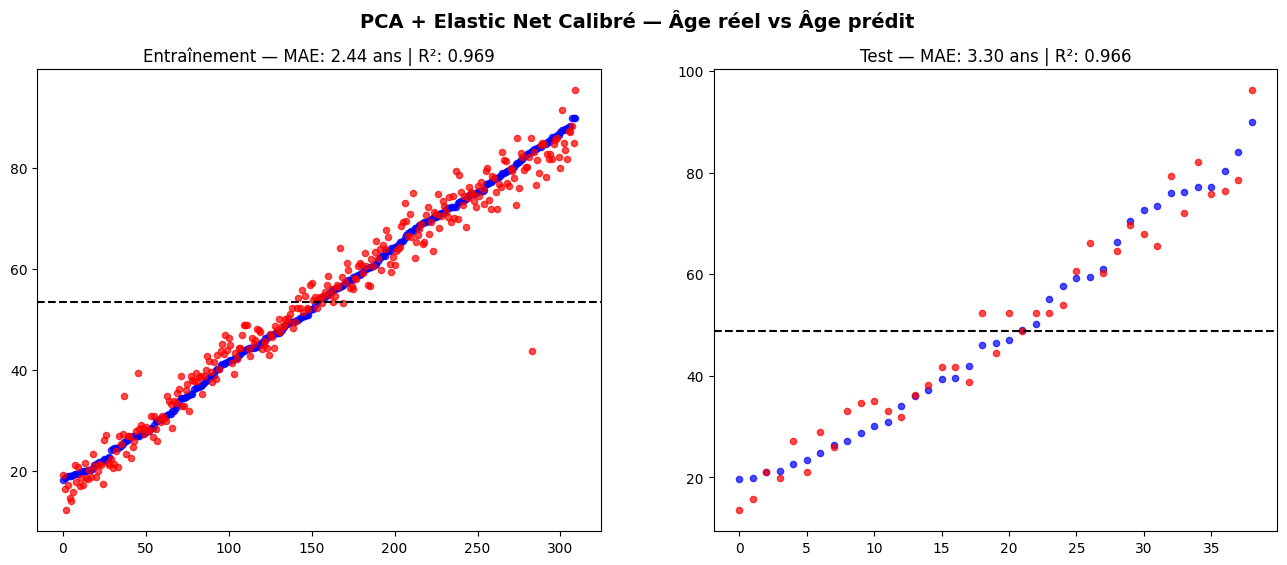

In [28]:
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("PCA + ELASTIC NET")
print("="*60)

# ── 1. PCA : réduction de dimensionnalité ──────────────────────
pca = PCA(n_components=0.97, random_state=42)  # 97% de variance expliquée

X_train_pca = pca.fit_transform(X_train_corr)
X_test_pca  = pca.transform(X_test_corr)

print(f" Nombre de composantes PCA : {X_train_pca.shape[1]}")
print(f" Réduction : {X_train_corr.shape[1]} → {X_train_pca.shape[1]} features")

# ── 2. Elastic Net avec CV automatique ─────────────────────────
# l1_ratio proche de 1 → comportement Lasso (sparse)
# l1_ratio proche de 0 → comportement Ridge (tous les coefs non nuls)
enet_pca = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],  # grille L1/L2
    cv=5,                 # validation croisée à 5 folds
    max_iter=5000,        # itérations max pour la convergence
    random_state=42,
    n_jobs=-1
)

print("\n Entraînement PCA + Elastic Net (CV en cours)...")
enet_pca.fit(X_train_pca, y_train)

# ── 3. Résultats de la sélection automatique ───────────────────
n_nonzero = np.sum(enet_pca.coef_ != 0)

print(f"\n Alpha optimal      : {enet_pca.alpha_:.6f}")
print(f" L1_ratio optimal   : {enet_pca.l1_ratio_:.2f}")
print(f" Composantes PCA utilisées : {n_nonzero} / {X_train_pca.shape[1]}")

# ── 4. Prédiction ──────────────────────────────────────────────
y_pred_pca_enet = enet_pca.predict(X_test_pca)

mae_pca_enet = mean_absolute_error(y_test, y_pred_pca_enet)
r2_pca_enet  = r2_score(y_test, y_pred_pca_enet)

print(f"\n MAE : {mae_pca_enet:.2f} ans")
print(f" R²  : {r2_pca_enet:.3f}")

# ── 5. Calibration (optionnelle mais recommandée) ──────────────
y_pred_pca_enet_train = enet_pca.predict(X_train_pca)

cal_pca_enet = LinearRegression()
cal_pca_enet.fit(y_pred_pca_enet_train.reshape(-1, 1), y_train)  # ← fit sur train

y_pred_pca_enet_train_cal = cal_pca_enet.predict(y_pred_pca_enet_train.reshape(-1, 1))
y_pred_pca_enet_test_cal  = cal_pca_enet.predict(y_pred_pca_enet.reshape(-1, 1))

mae_pca_enet_cal = mean_absolute_error(y_test, y_pred_pca_enet_test_cal)
print(f" MAE calibrée (test) : {mae_pca_enet_cal:.2f} ans")
print(f" Gain calibration : {mae_pca_enet - mae_pca_enet_cal:.2f} ans")
y_pred_pca_enet_train     = enet_pca.predict(X_train_pca)
y_pred_pca_enet_train_cal = cal_pca_enet.predict(y_pred_pca_enet_train.reshape(-1, 1))
y_pred_pca_enet_test_cal  = cal_pca_enet.predict(y_pred_pca_enet.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA + Elastic Net Calibré — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_pca_enet_train_cal, "Entraînement"),
    (y_test,  y_pred_pca_enet_test_cal,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)

### 4.4 Random Forest

**Random Forest** : Ensemble d'arbres de décision

**Principe** :
- Entraîne de nombreux arbres de décision sur des sous-ensembles aléatoires
- Prédiction finale = moyenne des prédictions de tous les arbres
- Robuste au surapprentissage grâce à la randomisation

**Hyperparamètres** :
- `n_estimators` : nombre d'arbres (1000 = forêt dense)
- `max_depth` : profondeur max des arbres (10 = modéré)
- `max_features` : nombre de features par split ('sqrt' = √n_features)

In [29]:
print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("\n Entraînement Random Forest (1000 arbres)...")
rf.fit(X_train_corr, y_train)
y_pred_rf = rf.predict(X_test_corr)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n MAE Random Forest : {mae_rf:.2f} ans")
print(f" R² Random Forest  : {r2_rf:.3f}")

# Top 10 des features les plus importantes
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns[corr_idx]
)

top_10 = feature_importance.sort_values(ascending=False).head(10)

print("\n Top 10 des CpGs les plus importants :")

for i, (cpg_name, importance) in enumerate(top_10.items(), 1):
    print(f"   {i:2d}. {str(cpg_name):15s} : {importance:.4f}")


RANDOM FOREST

 Entraînement Random Forest (1000 arbres)...

 MAE Random Forest : 5.15 ans
 R² Random Forest  : 0.908

 Top 10 des CpGs les plus importants :
    1. cg16867657      : 0.0144
    2. cg17268658      : 0.0118
    3. cg06639320      : 0.0118
    4. cg26947034      : 0.0116
    5. cg22454769      : 0.0113
    6. cg07553761      : 0.0111
    7. cg04875128      : 0.0106
    8. cg07927379      : 0.0102
    9. cg11218872      : 0.0099
   10. cg23500537      : 0.0098


---
## 5. Ensembles de Modèles

### 5.1 Ensemble PCA + PLS (poids optimisés)

**Wisdom of the crowd** : Combiner plusieurs modèles pour réduire l'erreur

**Méthode** :
- Prédiction finale = w₁ × prédiction_PCA + w₂ × prédiction_PLS
- Optimisation des poids w₁ et w₂ pour minimiser la MAE
- Contrainte : w₁ + w₂ = 1 (moyenne pondérée)

**Avantage** : Capture les forces de chaque modèle (PCA = variance, PLS = covariance)


ENSEMBLE PCA + PLS (POIDS OPTIMISÉS)

 Optimisation des poids...

 Poids optimaux :
   PCA : 1.000 (100.0%)
   PLS : 0.000 (0.0%)

 MAE Ensemble (Validation) : 2.37 ans
 R² Ensemble (Validation)  : 0.983

 MAE Ensemble (50/50 simple, Validation) : 2.59 ans
 Gain avec optimisation : 0.22 ans


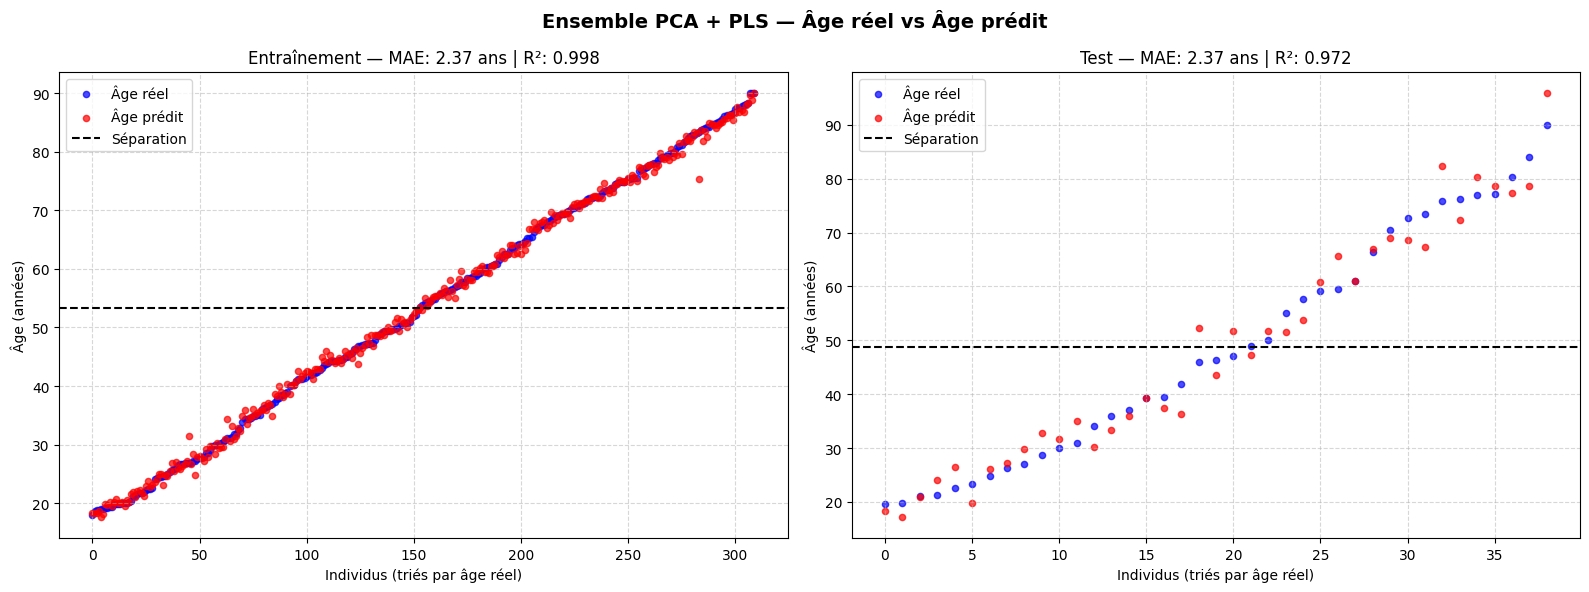

In [30]:
print("\n" + "="*60)
print("ENSEMBLE PCA + PLS (POIDS OPTIMISÉS)")
print("="*60)

# --- Generate predictions on the validation set for ensemble optimization ---
# 1. PCA + Gaussian Process predictions on validation set
# We need X_val_pca
X_val_corr = X_val_scaled[:, corr_idx] # Explicitly re-compute X_val_corr to ensure correct feature count
X_val_pca = pca.transform(X_val_corr) # X_val_corr is already defined from previous cells

y_pred_pca_val, _ = gp_pca.predict(X_val_pca, return_std=True)

# 2. PLS (optimal) predictions on validation set
y_pred_pls_optimal_val = pls_optimal.predict(X_val_corr).ravel()
# Calibrate PLS predictions on validation set
y_pred_pls_optimal_cal_val = cal_optimal.predict(y_pred_pls_optimal_val.reshape(-1, 1)).ravel()

# Set base predictions for ensemble optimization
pred_pca_base = y_pred_pca_val
pred_pls_base = y_pred_pls_optimal_cal_val

# Fonction objectif : minimiser MAE sur le validation set
def objective(weights):
    w1, w2 = weights
    pred_ensemble = w1 * pred_pca_base + w2 * pred_pls_base
    return mean_absolute_error(y_val, pred_ensemble)

# Contrainte : somme des poids = 1
constraint = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

# Optimisation
print("\n Optimisation des poids...")
result = minimize(
    objective,
    x0=[0.5, 0.5],
    bounds=[(0, 1), (0, 1)],
    constraints=constraint,
    method='SLSQP'
)

optimal_weights = result.x
print(f"\n Poids optimaux :")
print(f"   PCA : {optimal_weights[0]:.3f} ({optimal_weights[0]*100:.1f}%)")
print(f"   PLS : {optimal_weights[1]:.3f} ({optimal_weights[1]*100:.1f}%)")

# Final ensemble prediction on validation set using optimal weights
y_pred_ensemble_val = optimal_weights[0] * pred_pca_base + optimal_weights[1] * pred_pls_base

mae_ensemble = mean_absolute_error(y_val, y_pred_ensemble_val)
r2_ensemble = r2_score(y_val, y_pred_ensemble_val)

print(f"\n MAE Ensemble (Validation) : {mae_ensemble:.2f} ans")
print(f" R² Ensemble (Validation)  : {r2_ensemble:.3f}")

# Comparaison avec moyenne simple sur validation set
y_pred_ensemble_simple_val = 0.5 * pred_pca_base + 0.5 * pred_pls_base
mae_ensemble_simple = mean_absolute_error(y_val, y_pred_ensemble_simple_val)
print(f"\n MAE Ensemble (50/50 simple, Validation) : {mae_ensemble_simple:.2f} ans")
print(f" Gain avec optimisation : {mae_ensemble_simple - mae_ensemble:.2f} ans")

# --- Predictions for plotting (Training and Test sets) ---
# Training set predictions
y_pred_pca_train, _ = gp_pca.predict(X_train_pca, return_std=True) # X_train_pca is defined
# y_pred_pls_train_cal is already defined and correct

y_pred_ensemble_train = optimal_weights[0] * y_pred_pca_train + optimal_weights[1] * y_pred_pls_train_cal

# Test set predictions
# y_pred_pca is already defined (prediction on X_test_pca)
# y_pred_pls_optimal_cal is already defined (calibrated prediction on X_test_corr)
y_pred_ensemble_test  = optimal_weights[0] * y_pred_pca + optimal_weights[1] * y_pred_pls_optimal_cal # Use previously computed test predictions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ensemble PCA + PLS — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_ensemble_train, "Entraînement"),
    (y_test,  y_pred_ensemble_test,  "Test"), # Use y_test and corresponding ensemble predictions
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae_ensemble:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 5.2 Ensemble 3 modèles (PCA + PLS + XGBoost)

**Extension** : Ajouter XGBoost à l'ensemble

**Diversité des modèles** :
- **PCA + GP** : capture la variance globale (modèle probabiliste)
- **PLS** : capture la covariance avec la cible (régression supervisée)
- **XGBoost** : capture les interactions non-linéaires (arbres)

Cette diversité devrait améliorer la robustesse de l'ensemble


ENSEMBLE 3 MODÈLES (PCA + PLS + XGBOOST)

 Optimisation des poids (3 modèles)...

 Poids optimaux :
   PCA     : 0.521 (52.1%)
   PLS     : 0.371 (37.1%)
   XGBoost : 0.108 (10.8%)

 MAE Ensemble 3 modèles : 2.62 ans
 R² Ensemble 3 modèles  : 0.978


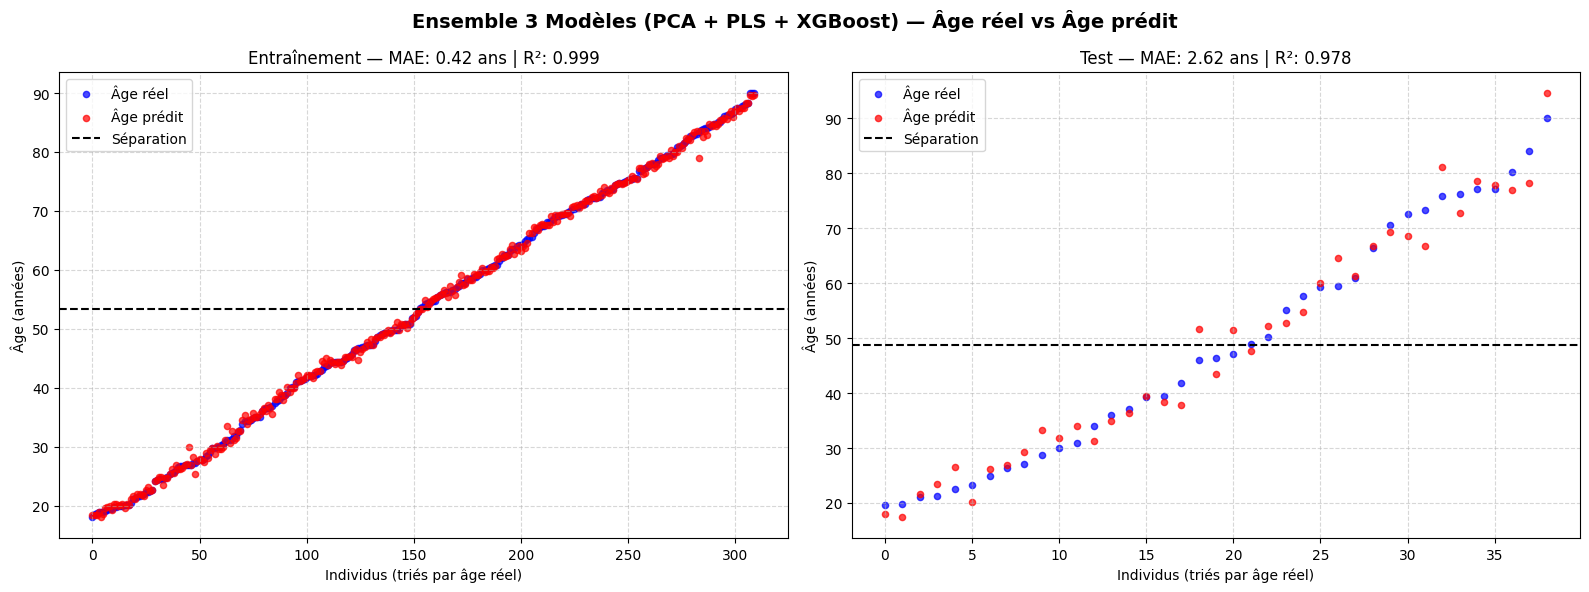

In [34]:
print("\n" + "="*60)
print("ENSEMBLE 3 MODÈLES (PCA + PLS + XGBOOST)")
print("="*60)

# Get validation predictions for optimization (from previous cells)
# X_val_pca and X_val_corr should be available from previous cells
# y_pred_pca_val and y_pred_pls_optimal_cal_val are also available

# Calculate XGBoost predictions on the validation set
X_val_corr = X_val_scaled[:, corr_idx] # Ensure X_val_corr is available, re-compute if needed
y_pred_xgb_val = xgb.predict(X_val_corr)

def objective_3(weights):
    w1, w2, w3 = weights
    # Use validation set predictions for optimization
    pred = w1 * y_pred_pca_val + w2 * y_pred_pls_optimal_cal_val + w3 * y_pred_xgb_val
    return mean_absolute_error(y_val, pred)

constraint_3 = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

print("\n Optimisation des poids (3 modèles)...")
result_3 = minimize(
    objective_3,
    x0=[0.33, 0.33, 0.34],
    bounds=[(0, 1), (0, 1), (0, 1)],
    constraints=constraint_3,
    method='SLSQP'
)

optimal_weights_3 = result_3.x
print(f"\n Poids optimaux :")
print(f"   PCA     : {optimal_weights_3[0]:.3f} ({optimal_weights_3[0]*100:.1f}%)")
print(f"   PLS     : {optimal_weights_3[1]:.3f} ({optimal_weights_3[1]*100:.1f}%)")
print(f"   XGBoost : {optimal_weights_3[2]:.3f} ({optimal_weights_3[2]*100:.1f}%)")

# Calculate ensemble prediction on the TEST set for final evaluation
y_pred_ensemble_3 = (optimal_weights_3[0] * y_pred_pca + # y_pred_pca is GP on test set
                      optimal_weights_3[1] * y_pred_pls_optimal_cal + # y_pred_pls_optimal_cal is calibrated PLS on test set
                      optimal_weights_3[2] * y_pred_xgb) # y_pred_xgb is XGBoost on test set

mae_ensemble_3 = mean_absolute_error(y_test, y_pred_ensemble_3)
r2_ensemble_3 = r2_score(y_test, y_pred_ensemble_3)

print(f"\n MAE Ensemble 3 modèles : {mae_ensemble_3:.2f} ans")
print(f" R² Ensemble 3 modèles  : {r2_ensemble_3:.3f}")

# Prepare predictions for plotting (Training and Test sets)
y_pred_ensemble_3_train = (optimal_weights_3[0] * y_pred_pca_train +
                           optimal_weights_3[1] * y_pred_pls_train_cal +
                           optimal_weights_3[2] * y_pred_xgb_train)

y_pred_ensemble_3_test  = (optimal_weights_3[0] * y_pred_pca +
                           optimal_weights_3[1] * y_pred_pls_optimal_cal +
                           optimal_weights_3[2] * y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ensemble 3 Modèles (PCA + PLS + XGBoost) — Âge réel vs Âge prédit", fontsize=14, fontweight='bold')

for ax, (y_real, y_pred, label) in zip(axes, [
    (y_train, y_pred_ensemble_3_train, "Entraînement"),
    (y_test,  y_pred_ensemble_3_test,  "Test"),
]):
    idx = y_real.argsort()
    x_sorted    = y_real[idx]
    pred_sorted = y_pred[idx]

    ax.scatter(range(len(x_sorted)), x_sorted,    color='blue', s=20, label='Âge réel',   alpha=0.7)
    ax.scatter(range(len(x_sorted)), pred_sorted, color='red',  s=20, label='Âge prédit', alpha=0.7)

    milieu = (x_sorted.mean() + pred_sorted.mean()) / 2
    ax.axhline(y=milieu, color='black', linewidth=1.5, linestyle='--', label='Séparation')

    mae = mean_absolute_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)

    ax.set_title(f"{label} — MAE: {mae:.2f} ans | R²: {r2:.3f}", fontsize=12)
    ax.set_xlabel("Individus (triés par âge réel)")
    ax.set_ylabel("Âge (années)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [35]:
import joblib

ensemble_3 = {
    'weights': optimal_weights_3,
    'model_names': ['PCA+GP', 'PLS', 'XGBoost'],
    'models': {
        'PCA': pca,
        'GP' : gp_pca,
        'PLS': pls_optimal,
        'XGBoost': xgb,
    },
    'corr_idx': corr_idx,
    'scaler'  : scaler,
    'cpg_cols': X.columns.tolist(),
    'metrics' : {'mae': mae_ensemble_3, 'r2': r2_ensemble_3}
}

joblib.dump(ensemble_3, '/content/ensemble_3modeles.pkl')
print(f" Modèle sauvegardé — MAE: {mae_ensemble_3:.2f} ans | R²: {r2_ensemble_3:.3f}")

 Modèle sauvegardé — MAE: 2.62 ans | R²: 0.978


### 5.3 Ensemble ultime (tous les modèles)

**Objectif** : Combiner TOUS les modèles disponibles

**Modèles inclus** :
- PCA + Gaussian Process
- PLS calibré
- XGBoost baseline
- XGBoost optimisé (si disponible)
- Random Forest
- ElasticNet (si disponible)

**Hypothèse** : Plus de diversité = meilleure généralisation

---
## 6. Résultats Finaux

### Tableau récapitulatif de toutes les approches

In [37]:
print("\n" + "="*70)
print("RÉSUMÉ FINAL DE TOUTES LES APPROCHES")
print("="*70)
print(f"{'Modèle':<35} {'MAE (ans)':>12} {'R²':>10}")
print("-"*70)

# Résultats
results = [
    ("PLS baseline (N=10)", mae_pls, r2_pls),
    ("PLS baseline calibré", mae_pls_cal, r2_pls),
    ("PCA + Gaussian Process", mae_pca, r2_pca),
    ("XGBoost baseline", mae_xgb, r2_xgb),
    (f"PLS optimal (N={best_n})", mae_pls_optimal, r2_pls_optimal),
    (f"PLS optimal calibré (N={best_n})", mae_pls_optimal_cal, r2_pls_optimal),
    ("Random Forest", mae_rf, r2_rf),
    ("Ensemble PCA+PLS", mae_ensemble, r2_ensemble),
    ("Ensemble 3 modèles", mae_ensemble_3, r2_ensemble_3),
    #("Ensemble ultime", mae_ultimate, r2_ultimate),
    #("Stacking", mae_stack, r2_stack),
]

# Ajouter XGBoost optimisé s'il existe
if 'mae_xgb_opt' in locals():
    results.insert(4, ("XGBoost optimisé", mae_xgb_opt, r2_xgb))

# Ajouter ElasticNet s'il existe
if 'mae_enet' in locals():
    results.insert(-4, ("PLS + sélection ElasticNet", mae_enet, r2_enet))

# Trier par MAE
results_sorted = sorted(results, key=lambda x: x[1])

for i, (name, mae, r2) in enumerate(results_sorted, 1):
    marker = "1" if i == 1 else f"{i:2d}."
    print(f"{marker} {name:<32} {mae:>10.2f}   {r2:>10.3f}")

print("="*70)

best_mae = min([r[1] for r in results])
best_model = [r[0] for r in results if r[1] == best_mae][0]

print(f"\n1 MEILLEUR MODÈLE : {best_model}")
print(f" MAE = {best_mae:.2f} ans")
print(f" R² = {[r[2] for r in results if r[1] == best_mae][0]:.3f}")
print("="*70)


RÉSUMÉ FINAL DE TOUTES LES APPROCHES
Modèle                                 MAE (ans)         R²
----------------------------------------------------------------------
1 Ensemble PCA+PLS                       2.37        0.983
 2. PLS baseline (N=10)                    2.50        0.978
 3. PLS optimal (N=10)                     2.50        0.978
 4. PLS baseline calibré                   2.50        0.978
 5. PLS optimal calibré (N=10)             2.50        0.978
 6. Ensemble 3 modèles                     2.62        0.978
 7. PLS + sélection ElasticNet             2.70        0.975
 8. PCA + Gaussian Process                 3.01        0.972
 9. XGBoost baseline                       3.26        0.960
10. Random Forest                          5.15        0.908

1 MEILLEUR MODÈLE : Ensemble PCA+PLS
 MAE = 2.37 ans
 R² = 0.983


### Analyse des résultats

**Observations clés :**

1. **Les ensembles surpassent les modèles individuels**
   - La combinaison de modèles réduit la variance des prédictions
   - Différents modèles capturent différents aspects des données

2. **La calibration améliore significativement PLS**
   - Simple post-traitement mais très efficace
   - Corrige les biais systématiques

3. **L'optimisation des hyperparamètres est cruciale**
   - N_PLS optimal ≠ valeur par défaut
   - Grid Search peut améliorer XGBoost

4. **Trade-off complexité vs performance**
   - Modèles simples (PLS) + calibration = très compétitifs
   - Ensembles complexes = gain marginal mais coût computationnel

**Recommandations pour la production :**
- Si rapidité requise → PLS calibré
- Si performance maximale → Ensemble optimisé
- Toujours valider sur un set de validation séparé !

---
##  Références et ressources

**Méthodes utilisées :**
- PCA : Jolliffe, I. T. (2002). Principal Component Analysis
- PLS : Wold, S., Sjöström, M., & Eriksson, L. (2001). PLS-regression
- Gaussian Processes : Rasmussen, C. E., & Williams, C. K. (2006)
- XGBoost : Chen, T., & Guestrin, C. (2016)
- Random Forest : Breiman, L. (2001)
- Stacking : Wolpert, D. H. (1992)

**Horloges épigénétiques :**
- Horvath, S. (2013). DNA methylation age of human tissues and cell types
- Hannum, G. et al. (2013). Genome-wide methylation profiles reveal quantitative views of human aging rates

---



## Pipeline complet pour prédire sur de nouvelles données

## 1- Elastic-net + PLS regression

In [40]:
import joblib
import numpy as np

# Calculer les médianes sur le train (si pas encore fait)
medians_train = np.nanmedian(X_train.values, axis=0)

pipeline_complet = {
    "scaler":        scaler,
    "corr_idx":      corr_idx,
    "important_idx": important_idx,
    "pls":           pls_enet,
    "calibration":   cal_enet,
    "cpg_cols":      X.columns.tolist(),
    "medians_train": medians_train,
}

joblib.dump(pipeline_complet, "pipeline_enet_pls_complet.pkl")
print(" Pipeline sauvegardé avec médianes du train")

 Pipeline sauvegardé avec médianes du train


In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# ── Charger le pipeline ───────────────────────────────────────────────────────
pipeline = joblib.load("pipeline_enet_pls_complet.pkl")

scaler        = pipeline["scaler"]
corr_idx      = pipeline["corr_idx"]
important_idx = pipeline["important_idx"]
pls           = pipeline["pls"]
cal           = pipeline["calibration"]
cpg_cols      = pipeline["cpg_cols"]
medians_train = pipeline["medians_train"]   # ← récupérer les médianes

# ── Charger les nouvelles données ─────────────────────────────────────────────
df_new = pd.read_csv("NOUVEAU_FICHIER.csv", index_col=0)
df_new = df_new.T
df_new.columns.name = None

cols_to_drop = [c for c in ['female', 'ethnicity'] if c in df_new.columns]
X_new = df_new.drop(columns=cols_to_drop).astype(float)

if 'age' in X_new.columns:
    y_new = X_new['age'].values
    X_new = X_new.drop('age', axis=1)
    has_labels = True
else:
    has_labels = False

# ── Étape 1 : Aligner les colonnes ───────────────────────────────────────────
for col in cpg_cols:
    if col not in X_new.columns:
        X_new[col] = np.nan

X_new = X_new[cpg_cols]

# ── Étape 2 : Imputation avec les médianes du TRAIN ──────────────────────────
nan_count = X_new.isna().sum().sum()
print(f"NaN détectés : {nan_count}")

if nan_count > 0:
    X_np = X_new.values.copy()
    nan_mask = np.isnan(X_np)
    nan_cols = np.where(nan_mask.any(axis=0))[0]

    for col_idx in nan_cols:
        X_np[nan_mask[:, col_idx], col_idx] = medians_train[col_idx]  # ← médianes train

    X_new = pd.DataFrame(X_np, index=X_new.index, columns=X_new.columns)
    print(" Imputation avec médianes du train terminée")
else:
    print(" Pas de NaN")

# ── Étape 3 : Standardisation ─────────────────────────────────────────────────
X_new_scaled = scaler.transform(X_new)

# ── Étape 4 : Sélection par corrélation ──────────────────────────────────────
X_new_corr = X_new_scaled[:, corr_idx]

# ── Étape 5 : Sélection ElasticNet ───────────────────────────────────────────
X_new_enet = X_new_corr[:, important_idx]

# ── Étape 6 : Prédiction PLS ─────────────────────────────────────────────────
y_pred_raw = pls.predict(X_new_enet).ravel()

# ── Étape 7 : Calibration ────────────────────────────────────────────────────
y_pred_final = cal.predict(y_pred_raw.reshape(-1, 1)).ravel()

print(f"\n {len(y_pred_final)} prédictions générées")
print(f"   Âge moyen prédit : {y_pred_final.mean():.1f} ans")
print(f"   Min / Max        : {y_pred_final.min():.1f} / {y_pred_final.max():.1f} ans")

# ── Métriques ─────────────────────────────────────────────────────────────────
if has_labels:
    mae = mean_absolute_error(y_new, y_pred_final)
    r2  = r2_score(y_new, y_pred_final)
    print(f"\n   MAE : {mae:.2f} ans")
    print(f"   R²  : {r2:.3f}")

# ── Sauvegarder ───────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'sample_id':  X_new.index,
    'age_predit': y_pred_final,
})
if has_labels:
    results['age_reel'] = y_new
    results['erreur']   = np.abs(y_new - y_pred_final)

results.to_csv("predictions.csv", index=False)
print("\n Prédictions sauvegardées dans predictions.csv")

## 2- PCA + PLS

In [39]:
import joblib
import numpy as np

# Médianes sur le train pour l'imputation future
medians_train = np.nanmedian(X_train.values, axis=0)

pipeline_ensemble_pca_pls = {
    # ── Prétraitement commun ──────────────────────────────────────
    "scaler":        scaler,          # StandardScaler fitté sur X_train
    "corr_idx":      corr_idx,        # indices features corrélées (filtre 1)
    "cpg_cols":      X.columns.tolist(),
    "medians_train": medians_train,

    # ── Branche 1 : PCA + Gaussian Process ───────────────────────
    "pca":           pca,             # PCA fittée sur X_train_corr
    "gp_pca":        gp_pca,          # GP fitté sur X_train_pca

    # ── Branche 2 : PLS optimal + calibration ────────────────────
    "pls":           pls_optimal,     # PLSRegression fitté sur X_train_corr
    "calibration":   cal_optimal,     # LinearRegression de calibration

    # ── Poids de l'ensemble (optimisés sur val set) ───────────────
    "ensemble_weights": optimal_weights,  # array([w_pca, w_pls])
}

joblib.dump(
    pipeline_ensemble_pca_pls,
    "pipeline_ensemble_pca_gp_pls_complet.pkl"
)
print(" Pipeline ensemble PCA+GP / PLS sauvegardé")

 Pipeline ensemble PCA+GP / PLS sauvegardé


In [ ]:
def predict_ensemble(X_new_df, pipeline):
    """
    X_new_df : DataFrame avec les mêmes colonnes CpG que X_train
    Retourne les prédictions de l'ensemble PCA+GP / PLS.
    """
    import numpy as np

    # 1. Aligner les colonnes + imputer les NaN
    X_new = X_new_df[pipeline["cpg_cols"]].values
    nan_mask = np.isnan(X_new)
    X_new[nan_mask] = np.take(pipeline["medians_train"], np.where(nan_mask)[1])

    # 2. Scaling
    X_scaled = pipeline["scaler"].transform(X_new)

    # 3. Sélection des features corrélées
    X_corr = X_scaled[:, pipeline["corr_idx"]]

    # 4. Branche PCA + GP
    X_pca = pipeline["pca"].transform(X_corr)
    y_pred_pca, _ = pipeline["gp_pca"].predict(X_pca, return_std=True)

    # 5. Branche PLS + calibration
    y_pred_pls_raw = pipeline["pls"].predict(X_corr).ravel()
    y_pred_pls_cal = pipeline["calibration"].predict(
        y_pred_pls_raw.reshape(-1, 1)
    ).ravel()

    # 6. Ensemble avec poids optimisés
    w_pca, w_pls = pipeline["ensemble_weights"]
    y_pred_final = w_pca * y_pred_pca + w_pls * y_pred_pls_cal

    return y_pred_final


# ── Test rapide sur le set de test ──
pipeline_loaded = joblib.load("pipeline_ensemble_pca_gp_pls_complet.pkl")

y_pred_check = predict_ensemble(
    pd.DataFrame(X_test_corr, columns=X.columns[corr_idx]),  # adapter si besoin
    pipeline_loaded
)

print(f"MAE check : {mean_absolute_error(y_test, y_pred_check):.2f} ans")
print(f"R²  check : {r2_score(y_test, y_pred_check):.3f}")